In [2]:
# Student information
print("\n" + "=" * 80)
print("\033[1mEnd Of Semester Examination\033[0m")
print("\033[1mName of Student: Joseph Dabuo\033[0m")
print("\033[1mRoll Number: 10022200160\033[0m")
print("\033[1mCourse: Biomedical Data Analysis with AI (BE4182)\033[0m")
print("\033[1mProject Title: Parkinson's Disease Voice Screening\033[0m")
print("\033[1mDate: 10/12/2025\033[0m")
print("=" * 80 + "\n")


End Of Semester Examination
Name of Student: Joseph Dabuo
Roll Number: 10022200160
Course: Biomedical Data Analysis with AI (BE4182)
Project Title: Parkinson's Disease Voice Screening
Date: 10/12/2025



In [3]:
# Importing libraries and setting basic plotting style

import numpy as np                      # numerical operations and arrays
import pandas as pd                     # working with tabular data (DataFrame)
import matplotlib.pyplot as plt         # basic plotting
import seaborn as sns                   # high-level plotting

from sklearn.model_selection import train_test_split    # split data into train and test
from sklearn.preprocessing import StandardScaler        # scale/standardize features
from sklearn.decomposition import PCA                   # Principal Component Analysis (PCA)

from sklearn.metrics import (                          # metrics to judge model performance
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression     # baseline linear classifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC                             # Support Vector Machine classifier

from imblearn.over_sampling import SMOTE                # oversampling technique for imbalanced data

import warnings
warnings.filterwarnings("ignore")                       # hide non-critical warnings to keep output clean

print("Libraries loaded for the analysis.")

Libraries loaded for the analysis.


In [4]:
# Loading the Parkinson's voice dataset

# Each row is a voice recording with acoustic features
# and a 'status' label:
#   status = 1 → Parkinson's disease
#   status = 0 → healthy control

voice_df = pd.read_csv("parkinsons.csv")

print("Data shape (rows, columns):", voice_df.shape) # Number of rows and columns

# View the first five rows
voice_df.head()

Data shape (rows, columns): (195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [5]:
# Data inspection

# Here we check column types, non-null counts
# and get a quick numeric summary. This helps us
# understand what features we have and detect obvious issues.

print("=== INFO ===")
print(voice_df.info()) # Data types and missing values

print("\n=== NUMERIC SUMMARY ===")
display(voice_df.describe().T) # Summary statistics

print("\nColumns in dataset:")
print(voice_df.columns.tolist()) # Print the column names of the DataFrame as a list

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null 

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000



Columns in dataset:
['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


=== Class counts ===
status
1    147
0     48
Name: count, dtype: int64

=== Class proportions (%) ===
status
1    75.384615
0    24.615385
Name: proportion, dtype: float64


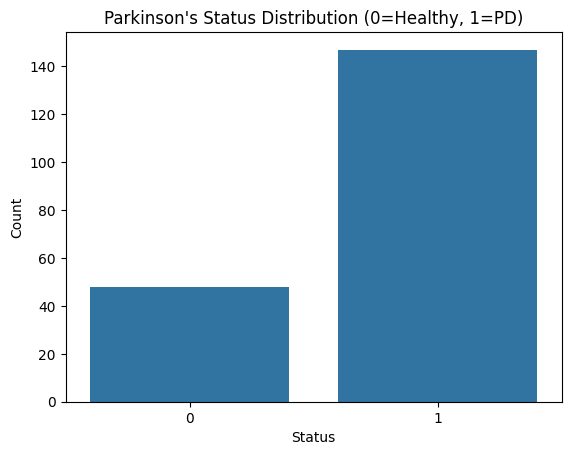

In [6]:
# Target distribution (0 = Healthy, 1 = Parkinson's)

# This shows if the dataset is imbalanced. Parkinson's datasets
# often have more PD recordings than healthy controls.

target_col = "status"

print("=== Class counts ===")
print(voice_df[target_col].value_counts())

print("\n=== Class proportions (%) ===")
print(voice_df[target_col].value_counts(normalize=True) * 100)

sns.countplot(x=voice_df[target_col])
plt.title("Parkinson's Status Distribution (0=Healthy, 1=PD)")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

In [7]:
# Identifying key voice-derived features

# We group features into:
# - Pitch-related: Fo, Fhi, Flo
# - Jitter: cycle-to-cycle frequency instability
# - Shimmer: cycle-to-cycle amplitude instability
# - Noise-related: HNR, NHR
# - Nonlinear measures: RPDE, DFA, spread1, spread2, PPE

pitch_cols = ["MDVP:Fo(Hz)", "MDVP:Fhi(Hz)", "MDVP:Flo(Hz)"]
jitter_cols = [c for c in voice_df.columns if "Jitter" in c]
shimmer_cols = [c for c in voice_df.columns if "Shimmer" in c]
noise_cols = [c for c in voice_df.columns if c in ["NHR", "HNR"]]
nonlinear_cols = [c for c in voice_df.columns if c in ["RPDE", "DFA", "spread1", "spread2", "PPE"]]

print("Pitch features present:", [c for c in pitch_cols if c in voice_df.columns])
print("Jitter features:", jitter_cols)
print("Shimmer features:", shimmer_cols)
print("Noise features:", noise_cols)
print("Nonlinear features:", nonlinear_cols)

Pitch features present: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)']
Jitter features: ['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'Jitter:DDP']
Shimmer features: ['MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:DDA']
Noise features: ['NHR', 'HNR']
Nonlinear features: ['RPDE', 'DFA', 'spread1', 'spread2', 'PPE']


Features chosen for comparison: ['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Shimmer(dB)', 'HNR', 'RPDE']


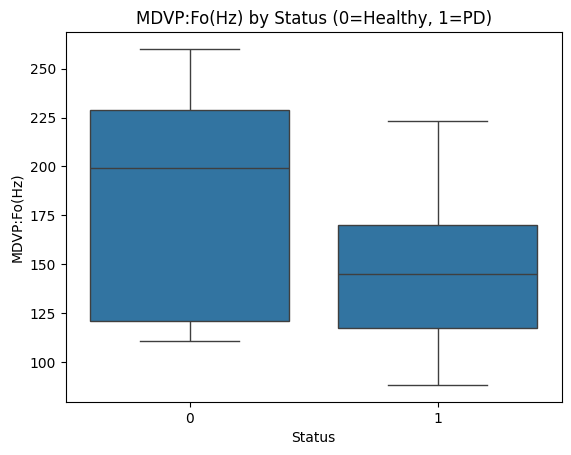

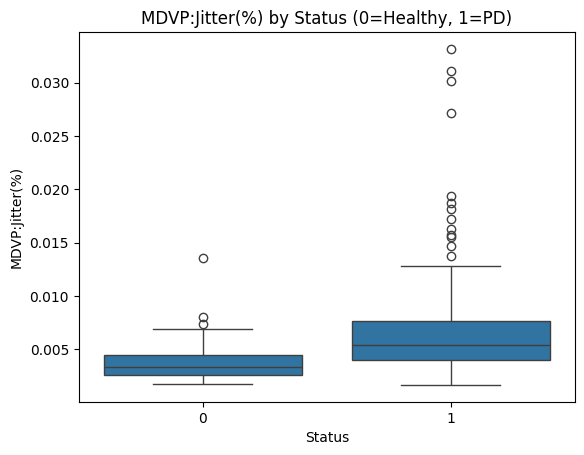

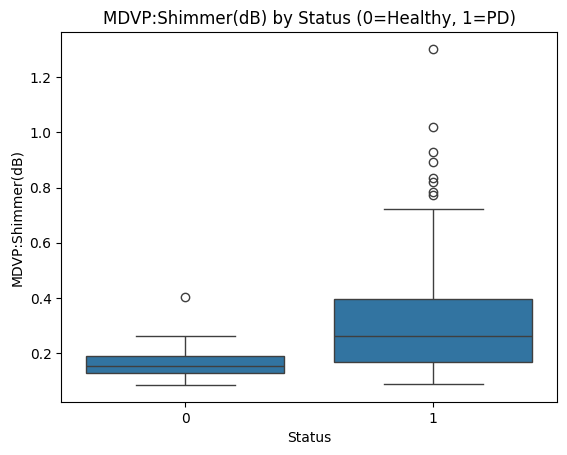

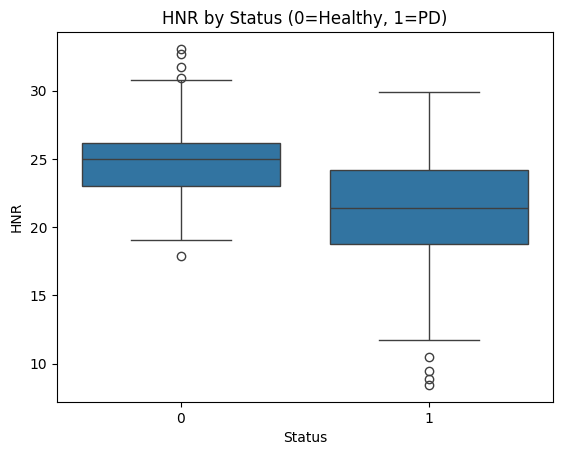

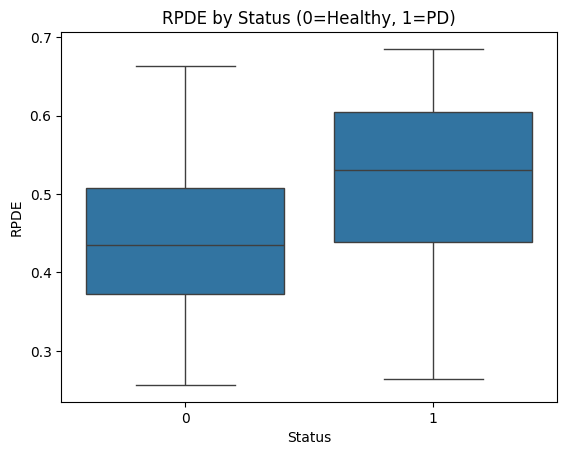

In [8]:
# Comparing feature patterns between healthy vs PD

# We use boxplots for a few representative features to see how
# their distributions differ between status = 0 and status = 1.
# This covers "comparing patterns between healthy and affected groups".

cols_to_plot = []

for col in ["MDVP:Fo(Hz)", "MDVP:Jitter(%)", "MDVP:Shimmer(dB)", "HNR", "RPDE"]:
    if col in voice_df.columns:
        cols_to_plot.append(col)

print("Features chosen for comparison:", cols_to_plot)

for col in cols_to_plot:
    plt.figure()
    sns.boxplot(data=voice_df, x=target_col, y=col)
    plt.title(f"{col} by Status (0=Healthy, 1=PD)")
    plt.xlabel("Status")
    plt.ylabel(col)
    plt.show()

Features used in correlation heatmap: ['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Shimmer(dB)', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'PPE']


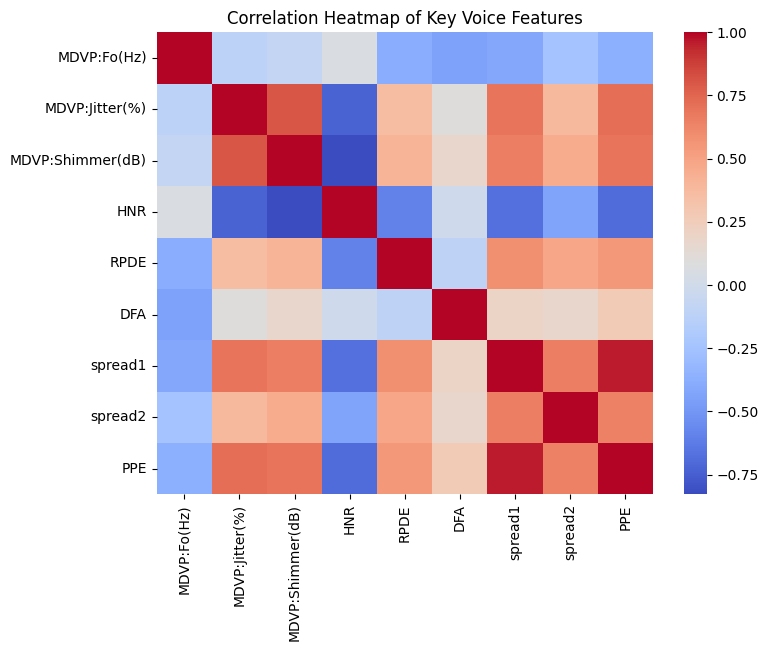

In [9]:
# Correlation heatmap for selected features

# We look at how some important voice features correlate with each other.
# This gives a sense of redundancy and patterns in the high-dimensional space.

selected_for_corr = cols_to_plot.copy()

# Add a few nonlinear features if they exist
for col in nonlinear_cols:
    if col not in selected_for_corr:
        selected_for_corr.append(col)

# Keep only columns that really exist
selected_for_corr = [c for c in selected_for_corr if c in voice_df.columns]

print("Features used in correlation heatmap:", selected_for_corr)

corr_matrix = voice_df[selected_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap of Key Voice Features")
plt.show()

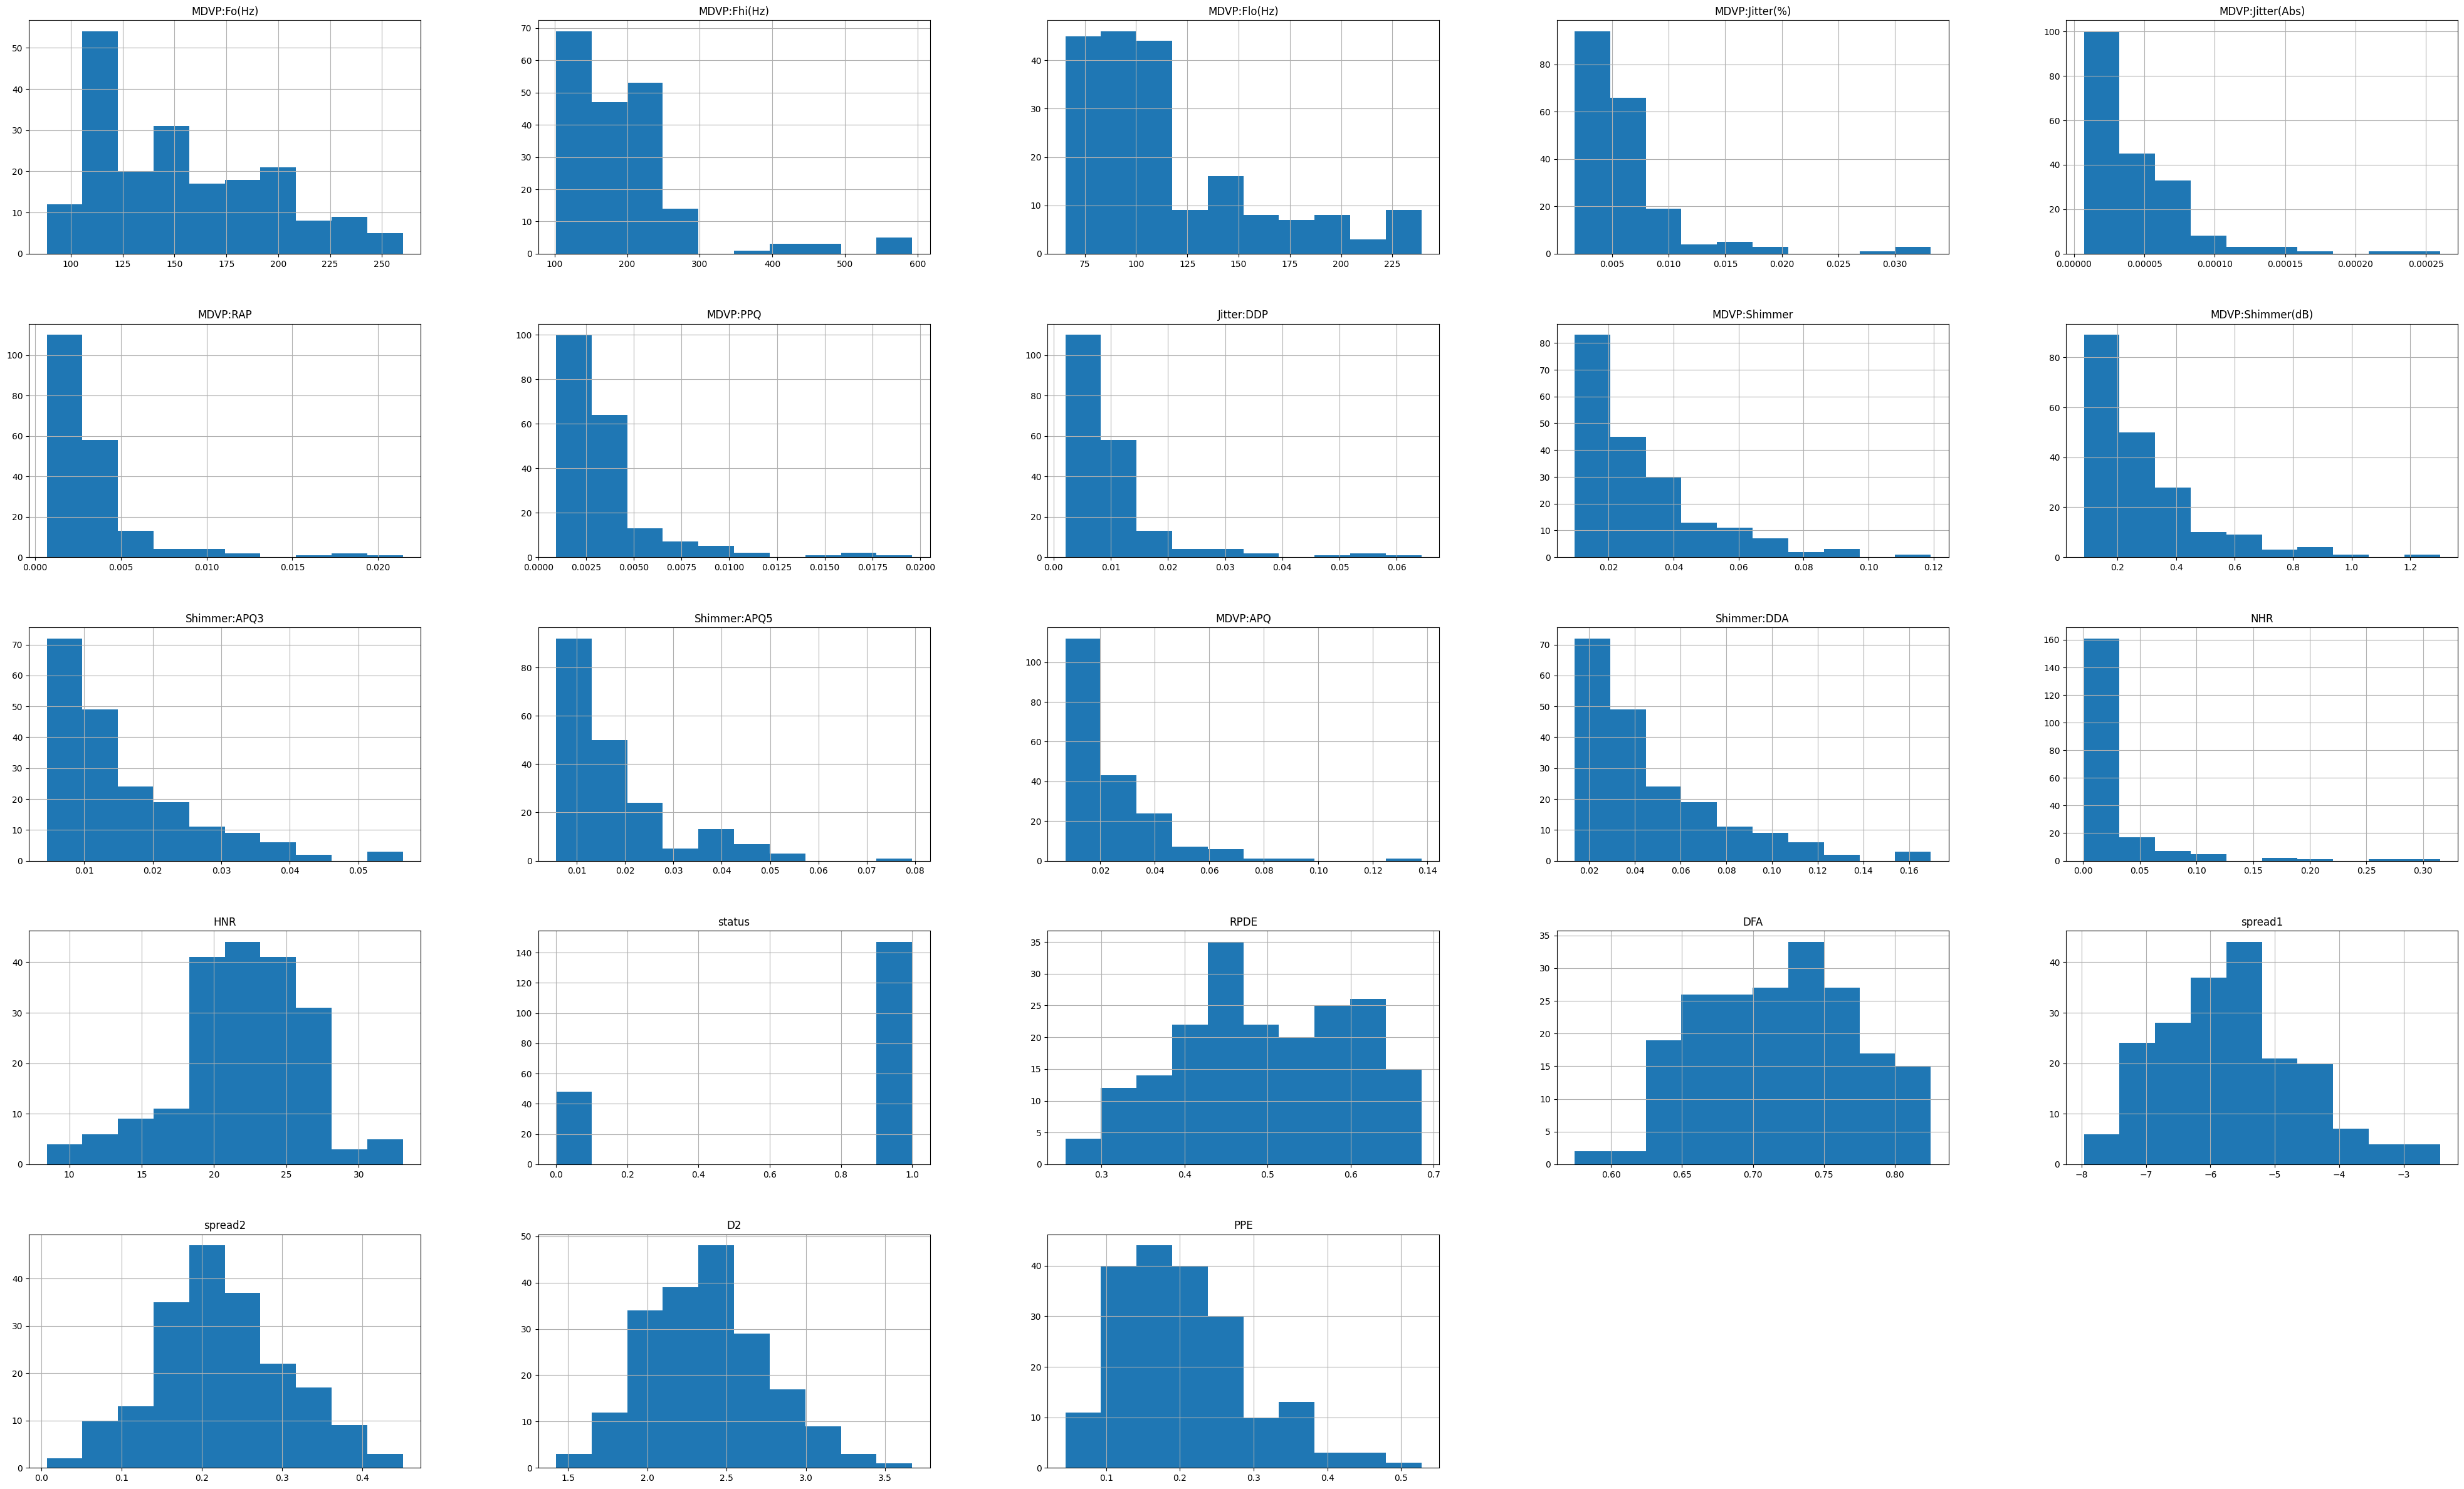

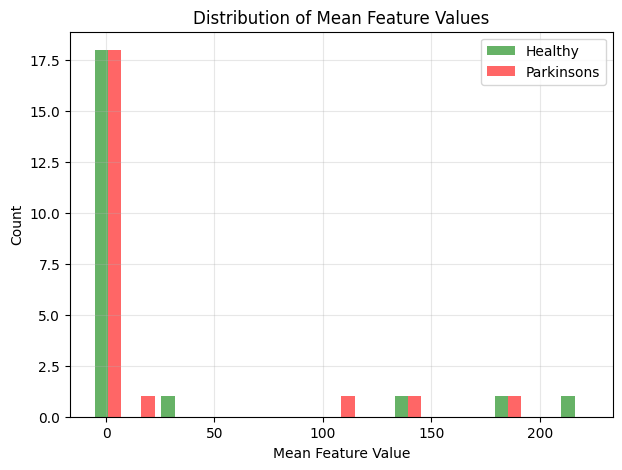

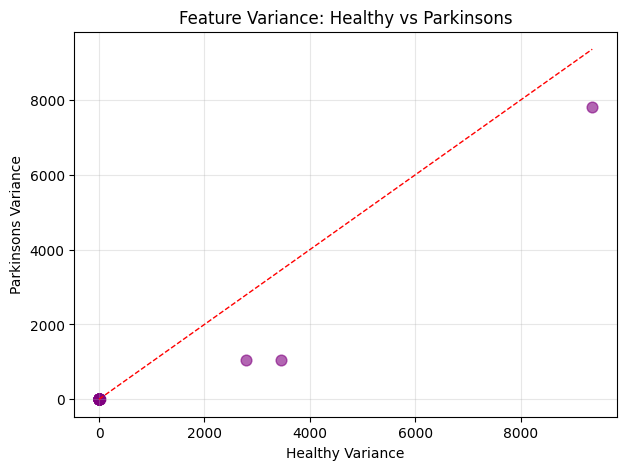

In [12]:
# Additional EDA Visualizations

# These plots help visualize how key voice features differ between
# healthy and Parkinson's patients beyond boxplots and heatmaps.

# Plot distribution of features
voice_df.hist(figsize=(50,30))
plt.show()

# Mean feature comparison
healthy_means = voice_df[voice_df['status'] == 0].drop(columns=['status', 'name'], errors="ignore").mean()
pd_means = voice_df[voice_df['status'] == 1].drop(columns=['status', 'name'], errors="ignore").mean()

plt.figure(figsize=(7, 5))
plt.hist(
    [healthy_means.values, pd_means.values],
    bins=15,
    label=["Healthy", "Parkinsons"],
    color=["green", "red"],
    alpha=0.6
)
plt.title("Distribution of Mean Feature Values")
plt.xlabel("Mean Feature Value")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Variance comparison between Healthy and Parkinsons
healthy_var = voice_df[voice_df['status'] == 0].drop(columns=['status', 'name'], errors="ignore").var()
pd_var = voice_df[voice_df['status'] == 1].drop(columns=['status', 'name'], errors="ignore").var()

min_len = min(len(healthy_var), len(pd_var))

plt.figure(figsize=(7, 5))
plt.scatter(
    healthy_var.values[:min_len],
    pd_var.values[:min_len],
    alpha=0.6,
    s=60,
    color="purple"
)
plt.plot(
    [0, max(healthy_var.max(), pd_var.max())],
    [0, max(healthy_var.max(), pd_var.max())],
    "r--",
    lw=1
)
plt.title("Feature Variance: Healthy vs Parkinsons")
plt.xlabel("Healthy Variance")
plt.ylabel("Parkinsons Variance")
plt.grid(alpha=0.3)
plt.show()

In [13]:
# Checking and handling missing values

# Even though the classic UCI dataset usually has no missing values,
# in general we should handle them. Here we fill numeric columns with
# the median to avoid losing rows.

print("Missing values per column BEFORE filling:")
print(voice_df.isna().sum())

numeric_cols = voice_df.select_dtypes(include=["number"]).columns.tolist()

for col in numeric_cols:
    median_val = voice_df[col].median()
    voice_df[col] = voice_df[col].fillna(median_val)

print("\nMissing values per column AFTER filling:")
print(voice_df.isna().sum())

Missing values per column BEFORE filling:
name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

Missing values per column AFTER filling:
name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
s

In [14]:
# Feature engineering for Parkinson's voice

# We add a few summary features:
# - mean_jitter: average of jitter-related columns
# - mean_shimmer: average of shimmer-related columns
# - HNR_to_NHR: ratio of harmonics to noise

# These help capture overall instability and noise in the voice signal.

if len(jitter_cols) > 0:
    voice_df["mean_jitter"] = voice_df[jitter_cols].mean(axis=1)

if len(shimmer_cols) > 0:
    voice_df["mean_shimmer"] = voice_df[shimmer_cols].mean(axis=1)

if "HNR" in voice_df.columns and "NHR" in voice_df.columns:
    voice_df["HNR_to_NHR"] = voice_df["HNR"] / (voice_df["NHR"] + 1e-6)

print("Columns after feature engineering:")
print(voice_df.columns)

Columns after feature engineering:
Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE', 'mean_jitter', 'mean_shimmer',
       'HNR_to_NHR'],
      dtype='object')


In [15]:
# Defining patient groups to prevent data leakage

# In this dataset, each subject may have multiple voice recordings (rows).
# If we randomly split rows, the same person might appear in both train and test,
# which leads to overly optimistic performance.

# To avoid this, we use 'name' as a group ID so that all recordings from the same
# person go either to the training set or the test set, but not both.

if "name" in voice_df.columns:
    groups = voice_df["name"]
    print("Number of unique patients (name):", groups.nunique())
else:
    # If there is no subject ID, we fall back to using the row index as group.
    # This is not ideal, but at least the code still runs.
    groups = pd.Series(np.arange(len(voice_df)))
    print("No 'name' column found. Using row index as group ID.")

Number of unique patients (name): 195


In [16]:
# Defining feature matrix X and target vector y

# We drop the ID column(s) and the target column, and keep the rest as features.

id_cols = ["name"] if "name" in voice_df.columns else []
X = voice_df.drop(columns=id_cols + [target_col])
y = voice_df[target_col]

print("Shape of X (features):", X.shape)
print("Shape of y (labels):", y.shape)

Shape of X (features): (195, 25)
Shape of y (labels): (195,)


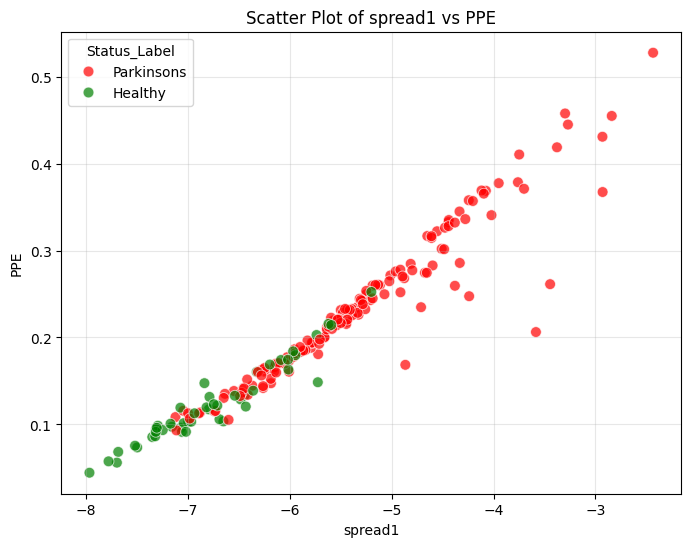

In [17]:
# Scatterplot for the two top correlated features

# Ensure X does not contain Status_Label
if "Status_Label" in X.columns:
    X = X.drop(columns=["Status_Label"])

# Generate the Status_Label column only for plotting
voice_df["Status_Label"] = voice_df[target_col].map({0: "Healthy", 1: "Parkinsons"})

# Define a palette
palette = {"Healthy": "green", "Parkinsons": "red"}

# Compute correlations
corr_with_target = X.corrwith(y).sort_values(ascending=False)

# Select top two numeric features
top_feat_1 = corr_with_target.index[0]
top_feat_2 = corr_with_target.index[1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=voice_df,
    x=top_feat_1,
    y=top_feat_2,
    hue="Status_Label",
    palette=palette,
    s=60,
    alpha=0.7
)
plt.title(f"Scatter Plot of {top_feat_1} vs {top_feat_2}")
plt.xlabel(top_feat_1)
plt.ylabel(top_feat_2)
plt.grid(alpha=0.3)
plt.show()

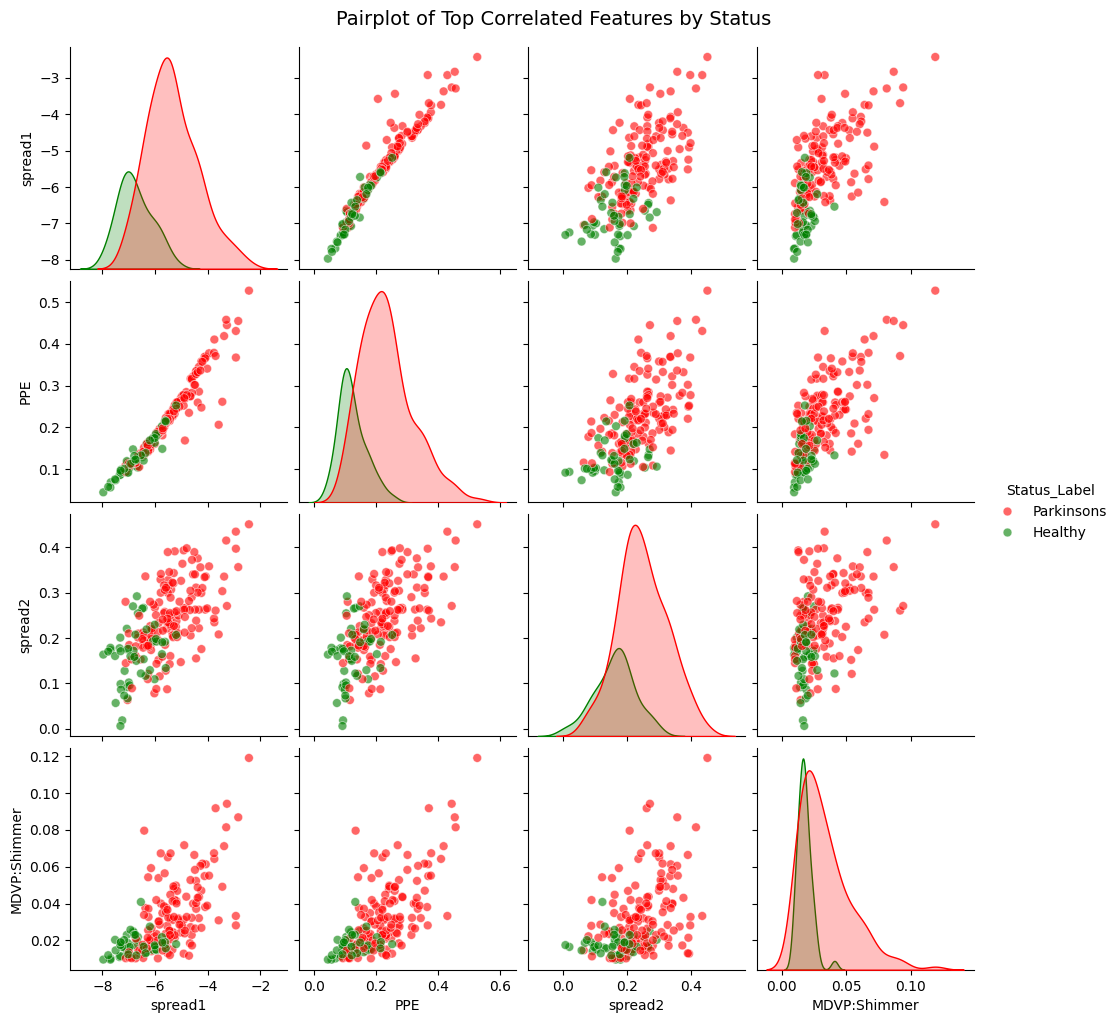

In [18]:
# Pairplot of top correlated features

# Make sure Status_Label exists
if "Status_Label" not in voice_df.columns:
    voice_df["Status_Label"] = voice_df[target_col].map({0: "Healthy", 1: "Parkinsons"})

# Define a palette
pair_palette = {"Healthy": "green", "Parkinsons": "red"}

# Compute correlation of each feature in X with target y
corr_with_target = X.corrwith(y).dropna().sort_values(ascending=False)

# If there are fewer than 2 numeric features, stop
if len(corr_with_target) < 2:
    print("Not enough numeric features to create a pairplot.")
else:
    # Select top 4 most correlated features (or fewer if dataset is small)
    num_feats = min(4, len(corr_with_target))
    top_features = corr_with_target.index[:num_feats].tolist()

    # Make sure these features actually exist in voice_df
    existing_features = [f for f in top_features if f in voice_df.columns]

    if len(existing_features) < 2:
        print("Not enough overlapping features between X and voice_df for pairplot.")
        print("Top features found in X:", top_features)
        print("Existing in voice_df:", existing_features)
    else:
        # Prepare dataframe for pairplot
        pair_plot_data = voice_df[existing_features + ["Status_Label"]].copy()

        # Draw pairplot
        g = sns.pairplot(
            pair_plot_data,
            hue="Status_Label",
            palette=pair_palette,
            diag_kind="kde",
            plot_kws={"alpha": 0.6, "s": 40}
        )
        g.fig.suptitle("Pairplot of Top Correlated Features by Status", fontsize=14, y=1.02)
        plt.show()

In [ ]:
# Group-aware train–test split (no same patient in both sets)

# We use GroupShuffleSplit so that subject groups are kept separate.
# This directly addresses the requirement to avoid bias when
# multiple recordings come from the same person.

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

for train_idx, test_idx in gss.split(X, y, groups=groups):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    groups_train = groups.iloc[train_idx]
    groups_test = groups.iloc[test_idx]

print("Training set shape:", X_train.shape)
print("Test set shape    :", X_test.shape)

print("\nUnique patients in TRAIN:", groups_train.nunique())
print("Unique patients in TEST :", groups_test.nunique())
print("Overlap in patients between TRAIN and TEST:",
      len(set(groups_train) & set(groups_test)))